# 1. Random Walks: The First Generative System

Today we write our first generative system: a handful of Python lines that wander across the canvas by chance and leave behind a drawing that nobody, including us, has planned in advance.

## Today's destination

By the end of this chapter you will be able to generate the image below yourself: a reconstruction of Georg Nees' *Schotter* ("gravel", 1968), one of the most famous works of early computer art. Notice how it moves from perfect order at the top to disorder at the bottom. That gradient is produced by exactly one idea, controlled randomness, and you will program it from scratch today.

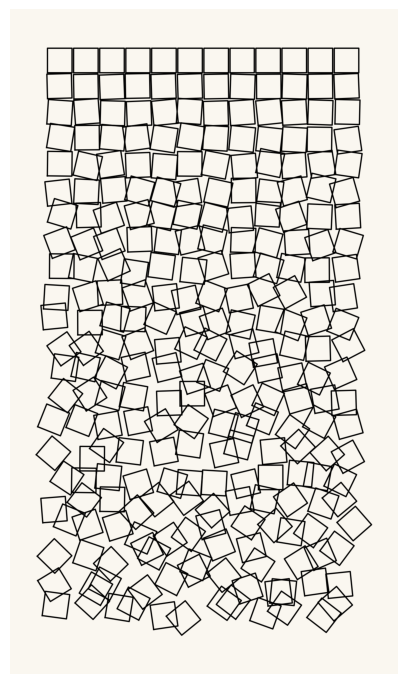

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch01_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(5, 9))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: the artist as system designer

In 1967, Sol LeWitt wrote a sentence that could serve as the motto of this whole course: *"The idea becomes a machine that makes the art."* From 1968 on, his wall drawings existed primarily as **written instructions** ("ten thousand lines about 10 inches long, covering the wall evenly"), executed by assistants, differently at every site. The artwork is not the wall; it is the *system* that produces walls. Whoever designs a system and lets it run has already, in an important sense, made generative art, no computer required.

At almost the same moment, computers entered the picture. In February 1965, the mathematician **Georg Nees** showed algorithmic drawings at the Studiengalerie of the TH Stuttgart, widely counted as the first exhibition of computer art. His best-known work, ***Schotter*** (1968), is a grid of squares that dissolves from strict order into tumbling chaos as your eye moves down the page: a program in ALGOL, a random number generator, and a flatbed plotter. When Nees was asked at that first exhibition whether he could make his machine draw the way an artist does, he reportedly answered that he could, *if you tell me how the artist draws.* The provocation still stings, and we will return to it in chapter 15.

The third figure to remember is **Vera Molnár** (1924–2023), who from 1959 worked with what she called the *machine imaginaire*: she executed algorithms by hand, step by step, years before she got access to an actual computer in 1968. Her point was radical for a painter trained in composition: replacing intuitive choice with a rule-plus-chance procedure was not a loss of authorship but a sharper instrument for it: the rule *is* the composition.

What unites LeWitt's instructions, Nees' plotter, and Molnár's imaginary machine? The theorist Philip Galanter's much-quoted definition (2003): generative art is any practice where the artist **cedes control to a system with functional autonomy** that contributes to, or results in, the finished work. Today you build your first such system. It will be modest, a walker taking random steps, but it already contains everything: a rule, a dose of chance, and a result that surprises its own author.

## A recipe that rolls dice

An **algorithm** (Algorithmus) is nothing more than a precise recipe: a finite list of steps that a machine can follow without asking questions. LeWitt's wall drawing instructions are algorithms for humans; today we write them for Python.

Our recipes need one special ingredient: **randomness**. A computer cannot actually roll dice: it produces *pseudo-random* numbers, generated by a deterministic formula that is designed to look statistically random. That subtle cheat will turn out to be a gift for artists (a "random" artwork we can reproduce exactly!), and we will exploit it properly in the next chapter. For now, let's just get some random numbers.

In [2]:
# ask Python for three random numbers between 0 and 1
import random

print(random.random())
print(random.random())
print(random.random())

0.2154198045867347
0.3127933496751407
0.8115485848368128


Run the cell above a second time (click it, then press `Shift+Enter`): you get *different* numbers. Every call to `random.random()` draws a fresh value between 0 and 1. Making chance *repeatable* is the next chapter's topic, but the drawing cells below already use the trick quietly, in their `random.seed(...)` line, so that your images come out exactly like the ones in this notebook. Change or delete that line whenever you want a one-of-a-kind run.

## The canvas: coordinates

Before we can draw, we need to know where things go. Matplotlib, the drawing library we use throughout the book, places points on an (x, y) coordinate system: x runs to the **right**, y runs **up**, exactly like in school mathematics. (Careful: digital *images* traditionally count y downwards from the top-left corner. We will meet that convention in chapter 7; today, y goes up.)

One course convention to remember from day one: when a plot is a **diagram** we keep the axes visible, because the numbers matter. When a plot is an **artwork** we switch the axes off (`plt.axis("off")`), because a picture of a random walk does not need a ruler. You will see both today. One more finishing touch, from the first palette piece onward: artworks sit on a soft paper-white ground (`PAPER` from the course package) instead of harsh screen-white, like plates printed in a book.

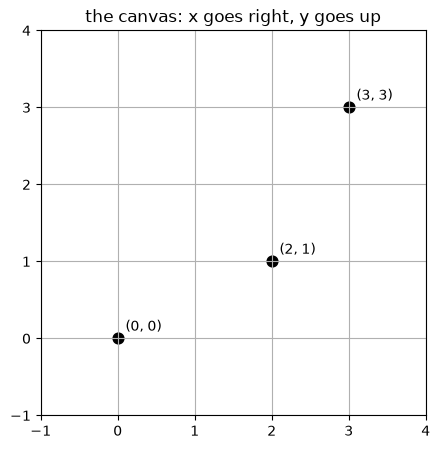

In [3]:
# three labeled points on the coordinate system -- axes ON, this is a diagram
plt.figure(figsize=(5, 5))
plt.scatter([0, 2, 3], [0, 1, 3], s=60, color="black")
plt.text(0.1, 0.1, "(0, 0)")
plt.text(2.1, 1.1, "(2, 1)")
plt.text(3.1, 3.1, "(3, 3)")
plt.xlim(-1, 4)
plt.ylim(-1, 4)
plt.grid(True)
plt.gca().set_aspect("equal")
plt.title("the canvas: x goes right, y goes up")
plt.show()

## Build-up

We assemble our first generative system piece by piece: variables, then a loop, then random points, then the walk itself.

In [4]:
# variables store values under a name, print() shows them
steps = 5
artist = "Vera"
print("Hello,", artist)
print("We will take", steps, "steps.")

Hello, Vera
We will take 5 steps.


In [5]:
# a for-loop repeats its indented lines -- here: five random step lengths
random.seed(101)
for i in range(5):
    value = random.random()
    print("step", i, "->", value)

step 0 -> 0.5811521325045647
step 1 -> 0.1947544955341367
step 2 -> 0.9652511070611112
step 3 -> 0.9239764016767943
step 4 -> 0.46713867819697397


Now we combine both ideas: a loop that collects random coordinates in two **lists** (`xs` and `ys`), which matplotlib then scatters onto the canvas in one go.

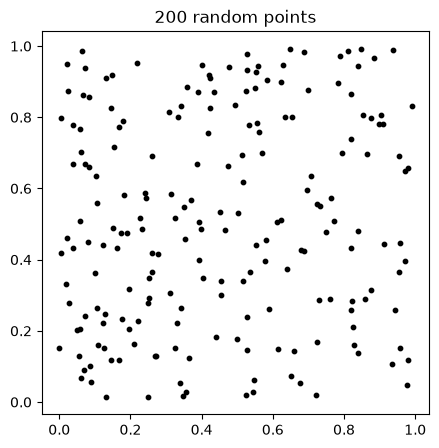

In [6]:
# scatter 200 random points -- our first (very simple) generated image
random.seed(7)   # fixes the chance sequence, so we all see the same points
xs = []
ys = []
for i in range(200):
    xs.append(random.random())
    ys.append(random.random())

plt.figure(figsize=(5, 5))
plt.scatter(xs, ys, s=10, color="black")
plt.gca().set_aspect("equal")
plt.title("200 random points")
plt.show()

### The random walk

Scattered points have no memory: each one ignores all the others. A **random walk** (Irrfahrt) is different: a walker starts somewhere and takes one random step at a time, so every position depends on the entire history before it. We give the walker four possible moves (up, down, right, left) and let `random.choice` pick one per step. Connecting the positions with a line makes the path visible.

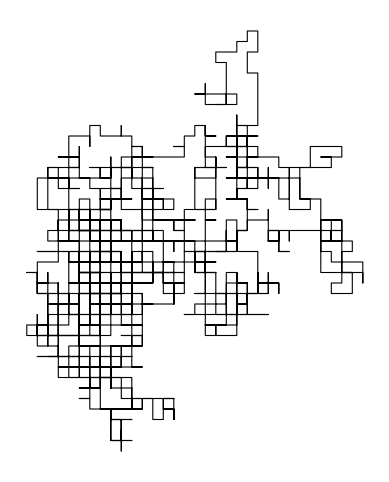

In [7]:
# a random walk: start at (0, 0), take 2000 random steps, draw the path
directions = [(0, 1), (0, -1), (1, 0), (-1, 0)]  # up, down, right, left

random.seed(23)
x = 0
y = 0
xs = [x]
ys = [y]
for i in range(2000):
    dx, dy = random.choice(directions)
    x = x + dx
    y = y + dy
    xs.append(x)
    ys.append(y)

plt.figure(figsize=(6, 6))
plt.plot(xs, ys, linewidth=0.8, color="black")
plt.gca().set_aspect("equal")
plt.axis("off")   # this is artwork now, not a diagram
plt.show()

### Many walkers, and a first palette

One walker draws a tangle; several walkers in different colors draw a composition. Color choices matter enormously in this course, so the course package `agap` provides a set of named **palettes** we will reuse in every chapter. The package lives one folder above the notebooks, which is why we briefly tell Python where to look.

In [8]:
# make the course helper package importable, then look at the palettes
import sys
sys.path.append("..")
from agap.helpers import PALETTES, PAPER, save_artwork

print("available palettes:", list(PALETTES.keys()))
print("bauhaus =", PALETTES["bauhaus"])

available palettes: ['bauhaus', 'rothko_dark', 'pastel', 'monochrome', 'viridis', 'magma', 'kelly']
bauhaus = ['#D02433', '#1B4B9B', '#F7C523', '#1A1A1A', '#F2EFE9']


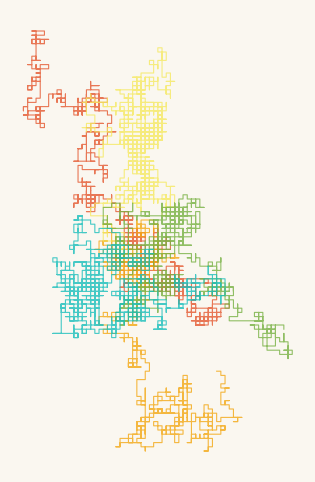

In [9]:
# five walks in one figure, each in its own palette color
palette = PALETTES["kelly"]

random.seed(5)
plt.figure(figsize=(6, 6), facecolor=PAPER)
for w in range(5):
    x = 0
    y = 0
    xs = [x]
    ys = [y]
    for i in range(1500):
        dx, dy = random.choice(directions)
        x = x + dx
        y = y + dy
        xs.append(x)
        ys.append(y)
    plt.plot(xs, ys, linewidth=0.8, color=palette[w % len(palette)], alpha=0.8)

plt.gca().set_aspect("equal")
plt.axis("off")
plt.show()

### Reconstructing *Schotter*

Now for the showpiece. Nees' *Schotter* is a grid of 12 × 22 squares. In the top row, every square sits perfectly in place. With every row further down, two doses of randomness grow stronger: each square gets a random **rotation** and a random **displacement** away from its grid position. Order does not break; it *erodes*.

To rotate a square we need a little trigonometry: a corner at position (px, py) relative to the square's center moves to

$$ \begin{aligned} r_x &= p_x\cos\alpha - p_y\sin\alpha \\ r_y &= p_x\sin\alpha + p_y\cos\alpha \end{aligned} $$

for a rotation by the angle $\alpha$. Don't memorize this; watch what it does in the test cell below, and trust it. (We will meet rotation properly in chapter 3.)

In [10]:
# corners of a square centered at (cx, cy), rotated by angle (in radians)
import math

def square_corners(cx, cy, size, angle):
    corners_x = []
    corners_y = []
    half = size / 2
    base = [(-half, -half), (half, -half), (half, half), (-half, half), (-half, -half)]
    for px, py in base:
        rx = px * math.cos(angle) - py * math.sin(angle)
        ry = px * math.sin(angle) + py * math.cos(angle)
        corners_x.append(cx + rx)
        corners_y.append(cy + ry)
    return corners_x, corners_y

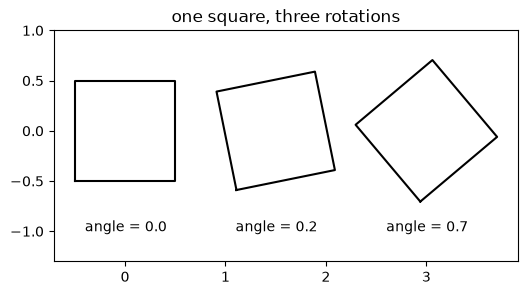

In [11]:
# test: the same square rotated by 0, 0.2 and 0.7 radians -- axes ON, diagram
plt.figure(figsize=(7, 3))
for position, angle in [(0, 0.0), (1, 0.2), (2, 0.7)]:
    xs, ys = square_corners(position * 1.5, 0, 1.0, angle)
    plt.plot(xs, ys, color="black")
    plt.text(position * 1.5 - 0.4, -1.0, f"angle = {angle}")
plt.gca().set_aspect("equal")
plt.ylim(-1.3, 1.0)
plt.title("one square, three rotations")
plt.show()

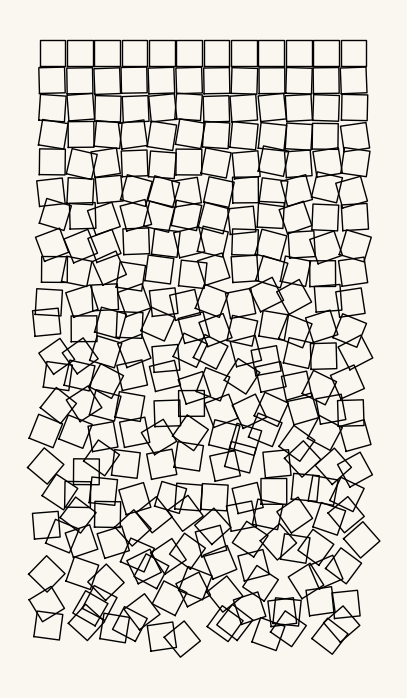

In [12]:
# Schotter: order at the top, disorder at the bottom
random.seed(1968)
rows = 22
cols = 12
max_rotation = 1.2   # radians of tilt, reached in the last row
max_shift = 0.45     # displacement in cell units, reached in the last row
square_size = 0.94   # squares slightly smaller than one grid cell

plt.figure(figsize=(5, 9), facecolor=PAPER)
for row in range(rows):
    disorder = row / (rows - 1)          # 0.0 in the top row, 1.0 in the last
    for col in range(cols):
        angle = random.uniform(-1, 1) * disorder * max_rotation
        cx = col + random.uniform(-1, 1) * disorder * max_shift
        cy = -row + random.uniform(-1, 1) * disorder * max_shift
        xs, ys = square_corners(cx, cy, square_size, angle)
        plt.plot(xs, ys, color="black", linewidth=1.0)

plt.gca().set_aspect("equal")
plt.axis("off")
plt.show()

## Playground

Time to make the systems yours. Below, both generators are wrapped into functions whose **parameters** are all in one place: the number of walkers, the step count, the palette, the amount of disorder. Each function also takes a `seed`: the same seed always reproduces the same artwork (the full explanation follows in chapter 2; for now, think of it as the artwork's serial number, and feel free to change it).

In [13]:
# the finished walk generator: every parameter in one place
def random_walk_art(n_walkers=5, n_steps=1500, palette_name="kelly", seed=1):
    directions = [(0, 1), (0, -1), (1, 0), (-1, 0)]
    palette = PALETTES[palette_name]
    random.seed(seed)
    fig = plt.figure(figsize=(6, 6), facecolor=PAPER)
    for w in range(n_walkers):
        x = 0
        y = 0
        xs = [x]
        ys = [y]
        for i in range(n_steps):
            dx, dy = random.choice(directions)
            x = x + dx
            y = y + dy
            xs.append(x)
            ys.append(y)
        plt.plot(xs, ys, linewidth=0.8, color=palette[w % len(palette)], alpha=0.8)
    plt.gca().set_aspect("equal")
    plt.axis("off")
    plt.show()
    return fig

In [14]:
# the finished Schotter generator
def schotter(rows=22, cols=12, max_rotation=1.2, max_shift=0.45,
             square_size=0.94, cell_inches=0.42, seed=1968):
    random.seed(seed)
    fig = plt.figure(figsize=(cols * cell_inches, rows * cell_inches), facecolor=PAPER)
    for row in range(rows):
        disorder = row / (rows - 1)
        for col in range(cols):
            angle = random.uniform(-1, 1) * disorder * max_rotation
            cx = col + random.uniform(-1, 1) * disorder * max_shift
            cy = -row + random.uniform(-1, 1) * disorder * max_shift
            xs, ys = square_corners(cx, cy, square_size, angle)
            plt.plot(xs, ys, color="black", linewidth=1.0)
    plt.gca().set_aspect("equal")
    plt.axis("off")
    plt.show()
    return fig

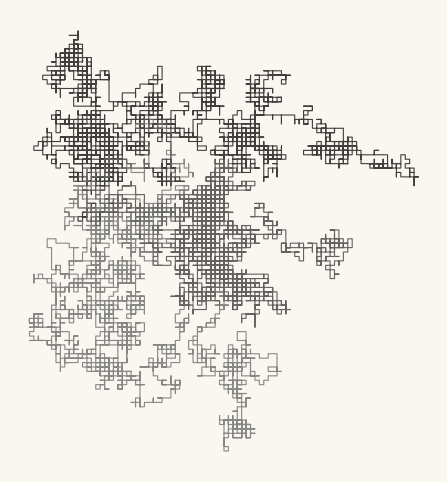

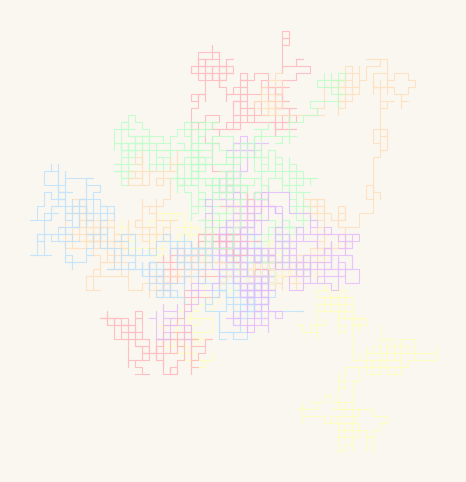

In [15]:
# four variations -- compare them before reading the question below
art_1 = random_walk_art(n_walkers=3, n_steps=4000, palette_name="monochrome", seed=3)
art_2 = random_walk_art(n_walkers=12, n_steps=600, palette_name="pastel", seed=9)

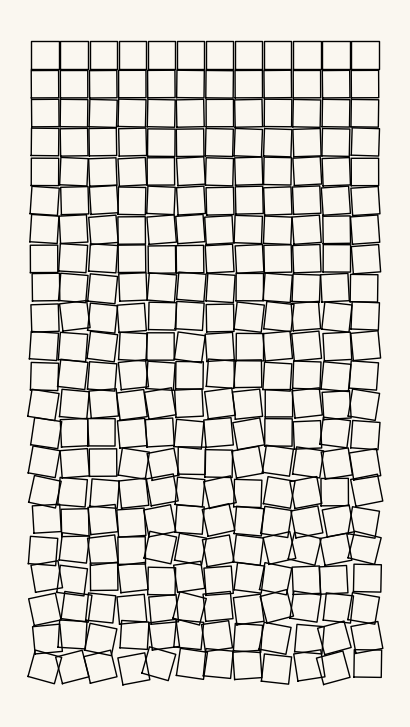

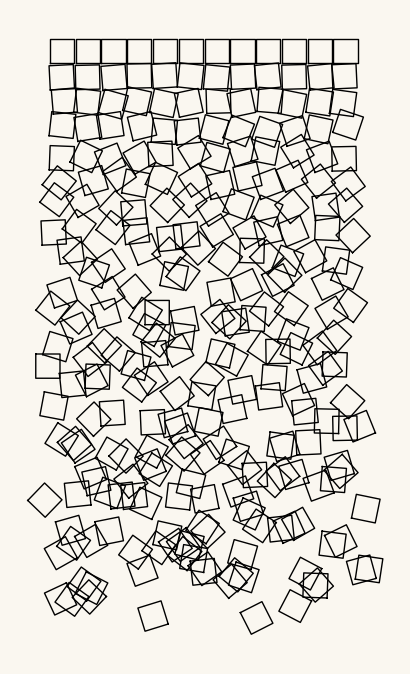

In [16]:
art_3 = schotter(rows=22, cols=12, max_rotation=0.3, max_shift=0.1, seed=7)
art_4 = schotter(rows=22, cols=12, max_rotation=3.0, max_shift=1.0, seed=7)

**Look and compare.** Which of the four images feels calmest, which feels most violent? For the two *Schotter* variants: both use the *same* random sequence (`seed=7`), so every difference you see comes from `max_rotation` and `max_shift` alone. At which point does the grid stop reading as a grid? Is the original's charm perhaps precisely that it stops *just* before that point?

## Export your artwork

Pick your favorite parameters, put your name in the cell below, and run it. The image lands in `assets/outputs/` at print quality; this folder becomes your personal gallery over the course of the book.

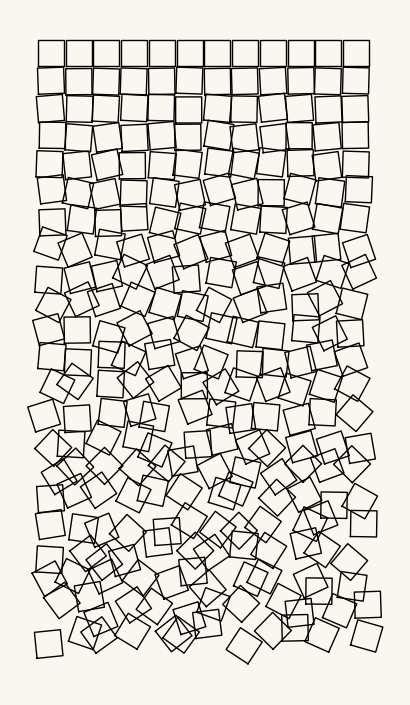

saved: assets/outputs/ch01_yourname.png


In [17]:
# save YOUR artwork: adjust parameters, replace 'yourname', run the cell
my_artwork = schotter(rows=22, cols=12, max_rotation=1.2, max_shift=0.45, seed=42)
saved_path = save_artwork(my_artwork, "yourname", chapter=1)

## Exercises

**(a) Parameter exploration: the drifting walker.** `random.choice(directions)` treats all four directions equally. Use `random.choices(directions, weights=[1, 1, 3, 1])` (note the plural, and look at the order of our `directions` list) to make the walker drift to the right. Try different weights: at what ratio does the drift become visible? At what ratio does the walk become boring?

**(b) Code modification: rotate the erosion.** Modify `schotter` so that disorder grows from **left to right** instead of from top to bottom (Nees' vertical becomes a horizontal). One line decides.

<details><summary>Solution</summary>

```python
def schotter_horizontal(rows=12, cols=22, max_rotation=1.2, max_shift=0.45,
                        square_size=0.94, cell_inches=0.42, seed=1968):
    random.seed(seed)
    fig = plt.figure(figsize=(cols * cell_inches, rows * cell_inches), facecolor=PAPER)
    for row in range(rows):
        for col in range(cols):
            disorder = col / (cols - 1)   # <- was: row / (rows - 1)
            angle = random.uniform(-1, 1) * disorder * max_rotation
            cx = col + random.uniform(-1, 1) * disorder * max_shift
            cy = -row + random.uniform(-1, 1) * disorder * max_shift
            xs, ys = square_corners(cx, cy, square_size, angle)
            plt.plot(xs, ys, color="black", linewidth=1.0)
    plt.gca().set_aspect("equal")
    plt.axis("off")
    plt.show()
    return fig

schotter_horizontal()
```

The disorder gradient now depends on the column index. Swapping `rows` and `cols` in the call keeps the landscape format.
</details>

**(c) Creative challenge: your own erosion rule.** *Schotter*'s rule is "disorder grows downward". Invent a different one: disorder growing from the center outward, disorder only in a diagonal band, order and disorder alternating in stripes... Change how `disorder` is computed from `row` and `col`, and give your piece a title.

## Further reading

- Sol LeWitt, ["Paragraphs on Conceptual Art"](https://en.wikipedia.org/wiki/Paragraphs_on_Conceptual_Art), *Artforum*, 1967: four pages, the founding text of art-as-instruction.
- Georg Nees, [*Schotter* in the Victoria & Albert Museum collection](https://collections.vam.ac.uk/item/O221321/schotter-print-nees-georg/): the original plotter drawing, with context on Nees and the Stuttgart school.
- Philip Galanter, ["What Is Generative Art?"](https://www.philipgalanter.com/downloads/ga2003_paper.pdf) (2003): the definition quoted above; read sections 1–3, skim the rest.
- Daniel Shiffman, [*The Nature of Code*, chapter 0 "Randomness"](https://natureofcode.com/random/): the same ideas as today in JavaScript; the prose is excellent and language-independent.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image shown at the top of the notebook. It runs automatically with *Restart & Run All*.

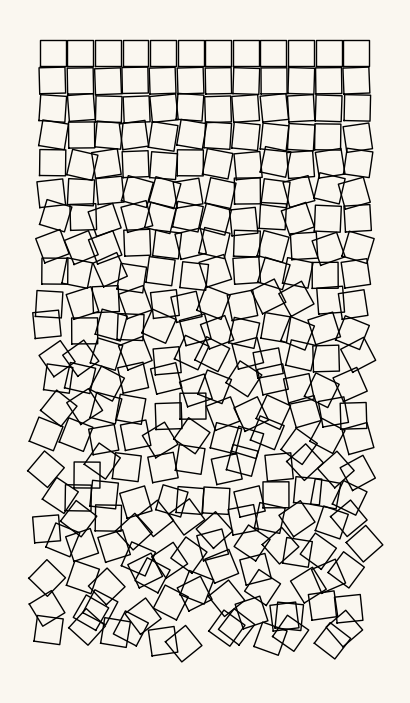

saved: assets/outputs/ch01_showpiece.png


In [18]:
# regenerate this chapter's showpiece
showpiece = schotter(rows=22, cols=12, max_rotation=1.2, max_shift=0.45, seed=1968)
saved_path = save_artwork(showpiece, "showpiece", chapter=1)